<a href="https://colab.research.google.com/github/100522371/P1_AA_Grupo17/blob/main/p1_aa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Montserrat Martis Contreras - 100522371

Laith Basem Elbeshti - 100477240

In [260]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

#Exploratory Data Analysis

Primero, importamos los datos disponibles al almacenamiento de sesión de Google Collab. Sumamos los últimos dos digitos de nuestras NIAs, 71 + 40 = 111, por lo que utilizaremos bank_11.pkl

In [261]:
try:
    from google.colab import files
    uploaded = files.upload()  # Solo se ejecuta en Colab
except ImportError:
    pass  # Ejecutando en local, el fichero ya debe estar presente

In [262]:
df = pd.read_pickle('bank_11.pkl')

# Para comprobar que se ha cargado bien vemos las primeras filas.
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,None,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


## Variables e instancias


In [263]:
# Número de instancias
print(df.shape[0])
# Número de variables
print(df.shape[1])

11000
17


## Data types y valores faltantes

Con el método info() podemos obtener información general como el data type de cada columna y cuantos valores nulos hay.

In [264]:
df.info()

<class 'pandas.DataFrame'>
Index: 11000 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11000 non-null  int64 
 1   job        11000 non-null  object
 2   marital    10634 non-null  object
 3   education  11000 non-null  object
 4   default    11000 non-null  object
 5   balance    11000 non-null  int64 
 6   housing    11000 non-null  object
 7   loan       11000 non-null  object
 8   contact    11000 non-null  object
 9   day        11000 non-null  int64 
 10  month      11000 non-null  object
 11  duration   11000 non-null  int64 
 12  campaign   11000 non-null  int64 
 13  pdays      11000 non-null  int64 
 14  previous   11000 non-null  int64 
 15  poutcome   11000 non-null  object
 16  deposit    11000 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.5+ MB


Podemos ver que la única columna con valores nulos es marital, con 366 valores nulos

## Cardinalidad

In [265]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns
alta_cardinalidad = [col for col in cat_cols if df[col].nunique() > 10]
print("Variables categóricas con más de 10 valores únicos:")
for col in alta_cardinalidad:
    print(f"- {col}: {df[col].nunique()} valores únicos")

Variables categóricas con más de 10 valores únicos:
- job: 12 valores únicos
- month: 12 valores únicos


Tiene sentido que job y month sean variables de alta cardinalidad

## Columnas constantes y de ID

Una columna constante tiene 1 solo valor para todas las filas. Un ID tiene tantos valores únicos como filas tenga el dataset.

In [266]:
# Columnas constantes
constantes = [col for col in df.columns if df[col].nunique() == 1]
print(f"Columnas constantes: {constantes}")

# Columnas tipo ID
ids = [col for col in df.columns if df[col].nunique() == len(df)]
print(f"Columnas que parecen IDs: {ids}")

Columnas constantes: []
Columnas que parecen IDs: []


Es interesante identificar que valores pueden tomar las variables categóricas

In [267]:
for col in cat_cols:
  valores_unicos = df[col].unique()
  cantidad = len(valores_unicos)
  print(f"--- Variable: {col} ---")
  print(f"Cantidad de valores únicos: {cantidad}")
  print(f"Valores: {valores_unicos}")
  print("-" * 50) # Línea separadora para que se lea mejor

--- Variable: job ---
Cantidad de valores únicos: 12
Valores: ['admin.' 'technician' 'services' 'management' 'retired' 'blue-collar'
 'unemployed' 'entrepreneur' 'housemaid' 'unknown' 'self-employed'
 'student']
--------------------------------------------------
--- Variable: marital ---
Cantidad de valores únicos: 4
Valores: ['married' None 'single' 'divorced']
--------------------------------------------------
--- Variable: education ---
Cantidad de valores únicos: 4
Valores: ['secondary' 'tertiary' 'primary' 'unknown']
--------------------------------------------------
--- Variable: default ---
Cantidad de valores únicos: 2
Valores: ['no' 'yes']
--------------------------------------------------
--- Variable: housing ---
Cantidad de valores únicos: 2
Valores: ['yes' 'no']
--------------------------------------------------
--- Variable: loan ---
Cantidad de valores únicos: 2
Valores: ['no' 'yes']
--------------------------------------------------
--- Variable: contact ---
Cantidad de

Podemos ver que algunas variables no tienen instancias None pero si son desconocidos teniendo el valor 'unknown'.

Hemos llegado a la conclusión que el hecho de que un dato sea desconocido tiene valor predictivo por sí mismo. Por ejemplo, si el banco no conoce el historial crediticio (default) de un cliente, eso en sí mismo ya es un indicador de riesgo.

## Tipo de problema

Como la variable objetivo es deposit, cuyos valores son categóricos, estamos ante un problema de clasificación. Para ver si está desbalanceado:

In [268]:
# Frecuencia absoluta
print("Recuento de clases en 'deposit':\n", df['deposit'].value_counts())

# Frecuencia relativa (porcentaje)
print("\nPorcentaje de clases en 'deposit':\n", df['deposit'].value_counts(normalize=True) * 100)

Recuento de clases en 'deposit':
 deposit
no     5780
yes    5220
Name: count, dtype: int64

Porcentaje de clases en 'deposit':
 deposit
no     52.545455
yes    47.454545
Name: proportion, dtype: float64


Tras analizar la variable objetivo deposit, comprobamos que nos enfrentamos a un problema de clasificación balanceado. Las clases están distribuidas de forma muy equitativa (52.5% frente a 47.5%), por lo que no será necesario aplicar técnicas de corrección de desbalanceo en el diseño de nuestras pipelines.

## pdays

Se pide que analizemos particularmente la variable pdays, y describir como se va a realizar el preproceso de esta variable (y llevar a cabo el preproceso ya en esta sección, si eso se considera correcto).

In [269]:
print("Distribución de la variable 'pdays':")
print(df['pdays'].value_counts().head(10)) # Vemos los valores más comunes, seguramente -1 sea el mayoritario

# Comprobar cuántos son -1 exactamente
sin_contacto = (df['pdays'] == -1).sum()
porcentaje = (sin_contacto / len(df)) * 100
print(f"\nHay {sin_contacto} instancias con valor -1 ({porcentaje:.2f}% del total).")

Distribución de la variable 'pdays':
pdays
-1      8203
 92      105
 182      88
 91       82
 181      79
 183      73
 184      51
 94       42
 93       40
 95       37
Name: count, dtype: int64

Hay 8203 instancias con valor -1 (74.57% del total).


El análisis de pdays revela que el 74.57% de las instancias tienen el valor -1, lo que indica que la inmensa mayoría de los clientes no fueron contactados en la campaña anterior (o se desconoce). Dado que -1 representa una ausencia de contacto y no un valor numérico real de días, dejarlo tal cual afectaría negativamente a modelos basados en distancias (como KNN). Por tanto, en la fase de preprocesado vamos a convertirlo a categórica, donde -1 -> "Sin contacto". Las otras categorías serán: "contacto reciente", "contacto medio" y "contacto antiguo". Ahora debemos decidir cuales serán los umbrales.


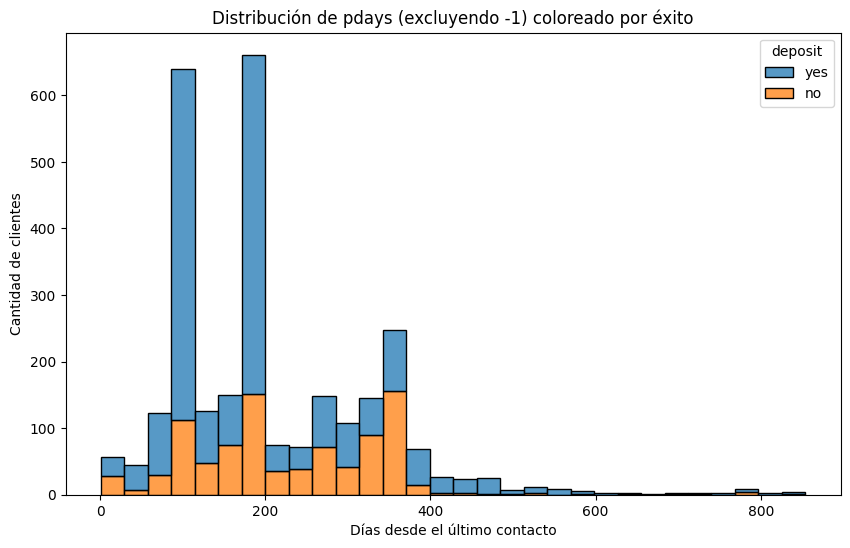

In [270]:
# Creamos un dataframe solo con los contactados
df_contactados = df[df['pdays'] != -1].copy()

# Hacemos un histograma coloreado por si suscribieron o no el depósito
plt.figure(figsize=(10, 6))
sns.histplot(data=df_contactados, x='pdays', hue='deposit', multiple="stack", bins=30)
plt.title("Distribución de pdays (excluyendo -1) coloreado por éxito")
plt.xlabel("Días desde el último contacto")
plt.ylabel("Cantidad de clientes")
plt.show()

Los contactos antes de los 200 días presentan una alta proporción de respuestas positivas. A partir de los 200 días la proporción se iguala un poco, y al superar el año (>400 días) las respuestas en general decrecen enormemente. Por ello, se categorizará la variable usando estos umbrales críticos detectados visualmente. 0-200 = "contacto reciente", 201-400 = "contacto medio" y >401 = "contacto antiguo".

In [271]:
# 1. Definimos los cortes (bins)
cortes = [-np.inf, -1, 200, 400, np.inf]

# 2. Definimos las etiquetas
etiquetas = [
    'no_contact',
    'recent',
    'intermediate',
    'old'
]

# 3. Sobrescribimos la columna original directamente
df['pdays'] = pd.cut(df['pdays'], bins=cortes, labels=etiquetas, right=True)

# Comprobamos el resultado
print(df['pdays'].value_counts())

pdays
no_contact      8203
recent          1799
intermediate     865
old              133
Name: count, dtype: int64


In [272]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,no_contact,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,no_contact,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,no_contact,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,no_contact,0,unknown,yes
4,54,admin.,None,tertiary,no,184,no,no,unknown,5,may,673,2,no_contact,0,unknown,yes



# Evaluación

## Decidir cómo se va a realizar la evaluación

### Métrica elegida: ROC-AUC

La métrica elegida para este problema es **ROC-AUC** (Area Under the Receiver Operating Characteristic Curve).

Esta métrica mide la capacidad del modelo para distinguir entre clases positivas (`yes`)
y negativas (`no`) a lo largo de todos los umbrales de decisión posibles. Un valor de 1.0
indica un modelo perfecto, mientras que 0.5 equivale a predicción aleatoria.

Se ha elegido ROC-AUC por las siguientes razones:
- Es **independiente del umbral**: el banco puede decidir más adelante cuántos clientes
  contactar según su presupuesto, sin que eso afecte a la evaluación del modelo.
- Es más **informativa que la accuracy**, ya que mide la calidad del ranking de predicciones
  y no solo si la clase predicha es correcta.
- Es compatible con todos los modelos que producen probabilidades o puntuaciones
  (KNN, árboles, regresión logística, SVM).
- Aunque el dataset está relativamente balanceado (52% / 48%), ROC-AUC sigue siendo
  la elección más robusta y profesional.


In [273]:
from sklearn.model_selection import train_test_split, StratifiedKFold

SEED = 100477240  # NIA utilizado como semilla para reproducibilidad

# Separamos las variables predictoras (X) de la variable objetivo (y)
X = df.drop(columns=['deposit'])
y = df['deposit']


### Evaluación externa (outer): Holdout

La estimación del rendimiento futuro del modelo se realizará mediante **Holdout**:
- **Train (2/3)**: usado para entrenar modelos, optimizar hiperparámetros y comparar alternativas.
- **Test (1/3)**: reservado exclusivamente para la evaluación final del modelo elegido.

In [274]:
# División Holdout estratificada: 2/3 train, 1/3 test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=1/3,
    random_state=SEED,
    stratify=y        # mantiene la proporción de clases en ambos conjuntos
)

print(f"Tamaño del conjunto de entrenamiento: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Tamaño del conjunto de test:          {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")
print(f"\nDistribución de clases en train:\n{y_train.value_counts(normalize=True)*100}")
print(f"\nDistribución de clases en test:\n{y_test.value_counts(normalize=True)*100}")


Tamaño del conjunto de entrenamiento: 7333 (66.7%)
Tamaño del conjunto de test:          3667 (33.3%)

Distribución de clases en train:
deposit
no     52.543297
yes    47.456703
Name: proportion, dtype: float64

Distribución de clases en test:
deposit
no     52.549768
yes    47.450232
Name: proportion, dtype: float64


### Evaluación interna (inner): Validación cruzada estratificada

Para la comparación de modelos y la optimización de hiperparámetros (HPO) se utilizará
**StratifiedKFold con 3 particiones**.

- Divide el conjunto de train en 3 partes iguales (folds).
- En cada iteración, entrena con 2 folds y evalúa con el restante.
- Repite esto 3 veces, usando cada fold como test exactamente una vez.
- El resultado final es la media de las 3 puntuaciones → estimación estable del rendimiento.

Se usa la versión **estratificada** para garantizar que cada fold mantenga
la misma proporción de clases (~52% no / 48% yes), evitando folds con distribuciones
desiguales que darían estimaciones poco fiables.

Esta evaluación interna (sobre los datos de train) guiará todas las decisiones de modelado y ajuste de hiperparámetros.

In [275]:
# Validación cruzada interna: StratifiedKFold con 3 particiones
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

# Métrica utilizada en toda la práctica
METRIC = "roc_auc"

print("Configuración de evaluación:")
print(f"  - Evaluación outer: Holdout (2/3 train / 1/3 test), estratificado")
print(f"  - Evaluación inner: StratifiedKFold (k=3), estratificado, semilla={SEED}")
print(f"  - Métrica: {METRIC}")


Configuración de evaluación:
  - Evaluación outer: Holdout (2/3 train / 1/3 test), estratificado
  - Evaluación inner: StratifiedKFold (k=3), estratificado, semilla=100477240
  - Métrica: roc_auc


# Métodos Básicos

Vamos a crear un Pipeline de KNN para evaluar los tres métodos de escalado y escoger el que utilizaremos el resto del proceso.

Debemos tener en cuenta que como se trata de KNN hay que transformar las variables categóricas en variables numéricas.

In [276]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

# Separaramos los nombres de las columnas por su tipo
# Aseguramos coger las numéricas por un lado y las categóricas/texto por otro
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

# Diccionario con los tres escaladores
escaladores = {
    'MinMaxScaler': MinMaxScaler(),
    'StandardScaler': StandardScaler(),
    'RobustScaler': RobustScaler()
}

resultados_escaladores = {}

# Bucle para probar cada escalador
for nombre, escalador in escaladores.items():

    # Creamos el transformador de columnas (ColumnTransformer)
    # A las numéricas les aplica el escalador actual, a las categóricas el OneHotEncoder
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', escalador, num_cols),
            # handle_unknown='ignore' evita errores si en test aparece una categoría nueva
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
        ])

    # Creamos el Pipeline uniendo el preprocesador y el modelo KNN por defecto
    pipeline_knn = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('clasificador', KNeighborsClassifier())
    ])

    # Usamos el inner_cv y la métrica (roc_auc) que definimos en el Paso 3
    scores = cross_val_score(pipeline_knn, X_train, y_train, cv=inner_cv, scoring=METRIC)
    media_auc = scores.mean()
    resultados_escaladores[nombre] = media_auc
    print(f"[{nombre}] AUC-ROC Medio: {media_auc:.4f}")

mejor_escalador_nombre = max(resultados_escaladores, key=resultados_escaladores.get)
print(f"\nEl mejor escalador para KNN es: {mejor_escalador_nombre} con un AUC de {resultados_escaladores[mejor_escalador_nombre]:.4f}")

[MinMaxScaler] AUC-ROC Medio: 0.8025
[StandardScaler] AUC-ROC Medio: 0.8641
[RobustScaler] AUC-ROC Medio: 0.8564

El mejor escalador para KNN es: StandardScaler con un AUC de 0.8641


## KNN

### Modelo por omisión y medición de tiempo

In [277]:
preprocessor_knn = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
])

pipe_knn = Pipeline([('prep', preprocessor_knn), ('clasificador', KNeighborsClassifier())])

t0 = time.time()
scores_knn = cross_val_score(pipe_knn, X_train, y_train, cv=inner_cv, scoring=METRIC)
t_knn = time.time() - t0

print(f"KNN (Por omisión) - AUC-ROC: {scores_knn.mean():.4f} - Tiempo CV: {t_knn:.2f} segundos")


KNN (Por omisión) - AUC-ROC: 0.8641 - Tiempo CV: 0.36 segundos


### Hiperparámetros

Iniciando búsqueda de hiperparámetros para KNN...

Mejores hiperparámetros KNN: {'clasificador__n_neighbors': 41, 'clasificador__weights': 'distance'}
Mejor AUC-ROC (Cross-Validation): 0.8901
Tiempo de optimización (GridSearchCV): 16.83 segundos


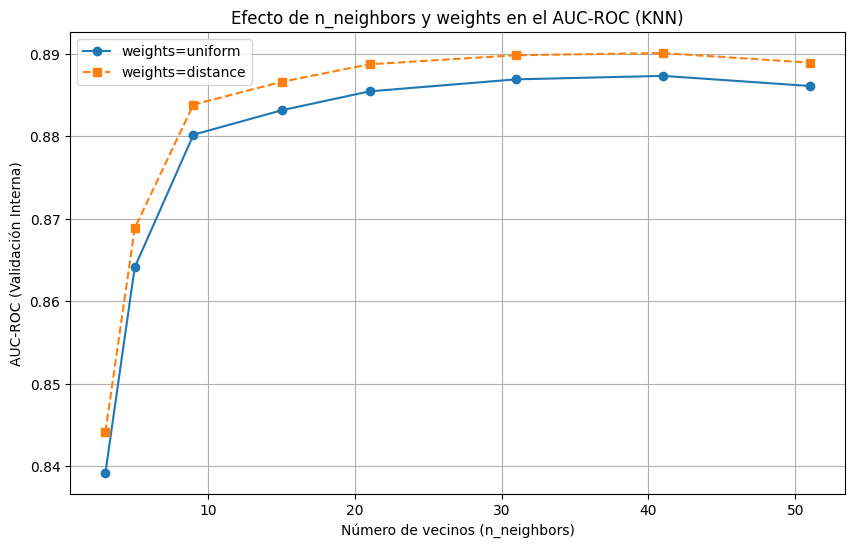

In [278]:
from sklearn.model_selection import GridSearchCV

# Definimos el espacio de búsqueda de parámetros para KNN
param_grid_knn = {
    'clasificador__n_neighbors': [3, 5, 9, 15, 21, 31, 41, 51],
    'clasificador__weights': ['uniform', 'distance']
}

# Configuramos la búsqueda usando nuestro pipeline y la validación cruzada interna
grid_knn = GridSearchCV(
    estimator=pipe_knn,
    param_grid=param_grid_knn,
    cv=inner_cv,
    scoring=METRIC,
    n_jobs=-1, # Para paralelizar y reducir tiempo
    return_train_score=True
)

print("Iniciando búsqueda de hiperparámetros para KNN...")
t0 = time.time()
grid_knn.fit(X_train, y_train)
t_knn_hpo = time.time() - t0

# Imprimimos los mejores resultados
print(f"\nMejores hiperparámetros KNN: {grid_knn.best_params_}")
print(f"Mejor AUC-ROC (Cross-Validation): {grid_knn.best_score_:.4f}")
print(f"Tiempo de optimización (GridSearchCV): {t_knn_hpo:.2f} segundos")

# Plot: Efecto de los hiperparámetros
resultados_knn = pd.DataFrame(grid_knn.cv_results_)

# Filtramos por tipo de peso ('weights') para hacer dos líneas
res_uniform = resultados_knn[resultados_knn['param_clasificador__weights'] == 'uniform']
res_distance = resultados_knn[resultados_knn['param_clasificador__weights'] == 'distance']

plt.figure(figsize=(10, 6))
plt.plot(res_uniform['param_clasificador__n_neighbors'], res_uniform['mean_test_score'], marker='o', label='weights=uniform')
plt.plot(res_distance['param_clasificador__n_neighbors'], res_distance['mean_test_score'], marker='s', linestyle='--', label='weights=distance')

plt.title('Efecto de n_neighbors y weights en el AUC-ROC (KNN)')
plt.xlabel('Número de vecinos (n_neighbors)')
plt.ylabel('AUC-ROC (Validación Interna)')
plt.legend()
plt.grid(True)
plt.show()

Observamos que un número muy bajo de vecinos penaliza el modelo por exceso de varianza. Al aumentar K, el modelo generaliza mejor hasta estabilizarse alrededor de 41 vecinos, momento a partir del cual añadir más no aporta valor e incluso puede introducir sesgo

## Árboles de decision

### Modelo por omisión y medición de tiempo

In [279]:
from sklearn.tree import DecisionTreeClassifier

preprocessor_tree = ColumnTransformer(transformers=[
    ('num', 'passthrough', num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
])

pipe_tree = Pipeline([('prep', preprocessor_tree), ('clasificador', DecisionTreeClassifier(random_state=SEED))])

t0 = time.time()
scores_tree = cross_val_score(pipe_tree, X_train, y_train, cv=inner_cv, scoring=METRIC)
t_tree = time.time() - t0

print(f"Árbol (Por omisión) - AUC-ROC: {scores_tree.mean():.4f} - Tiempo CV: {t_tree:.2f} segundos")

Árbol (Por omisión) - AUC-ROC: 0.7804 - Tiempo CV: 0.41 segundos


### Poca profundidad

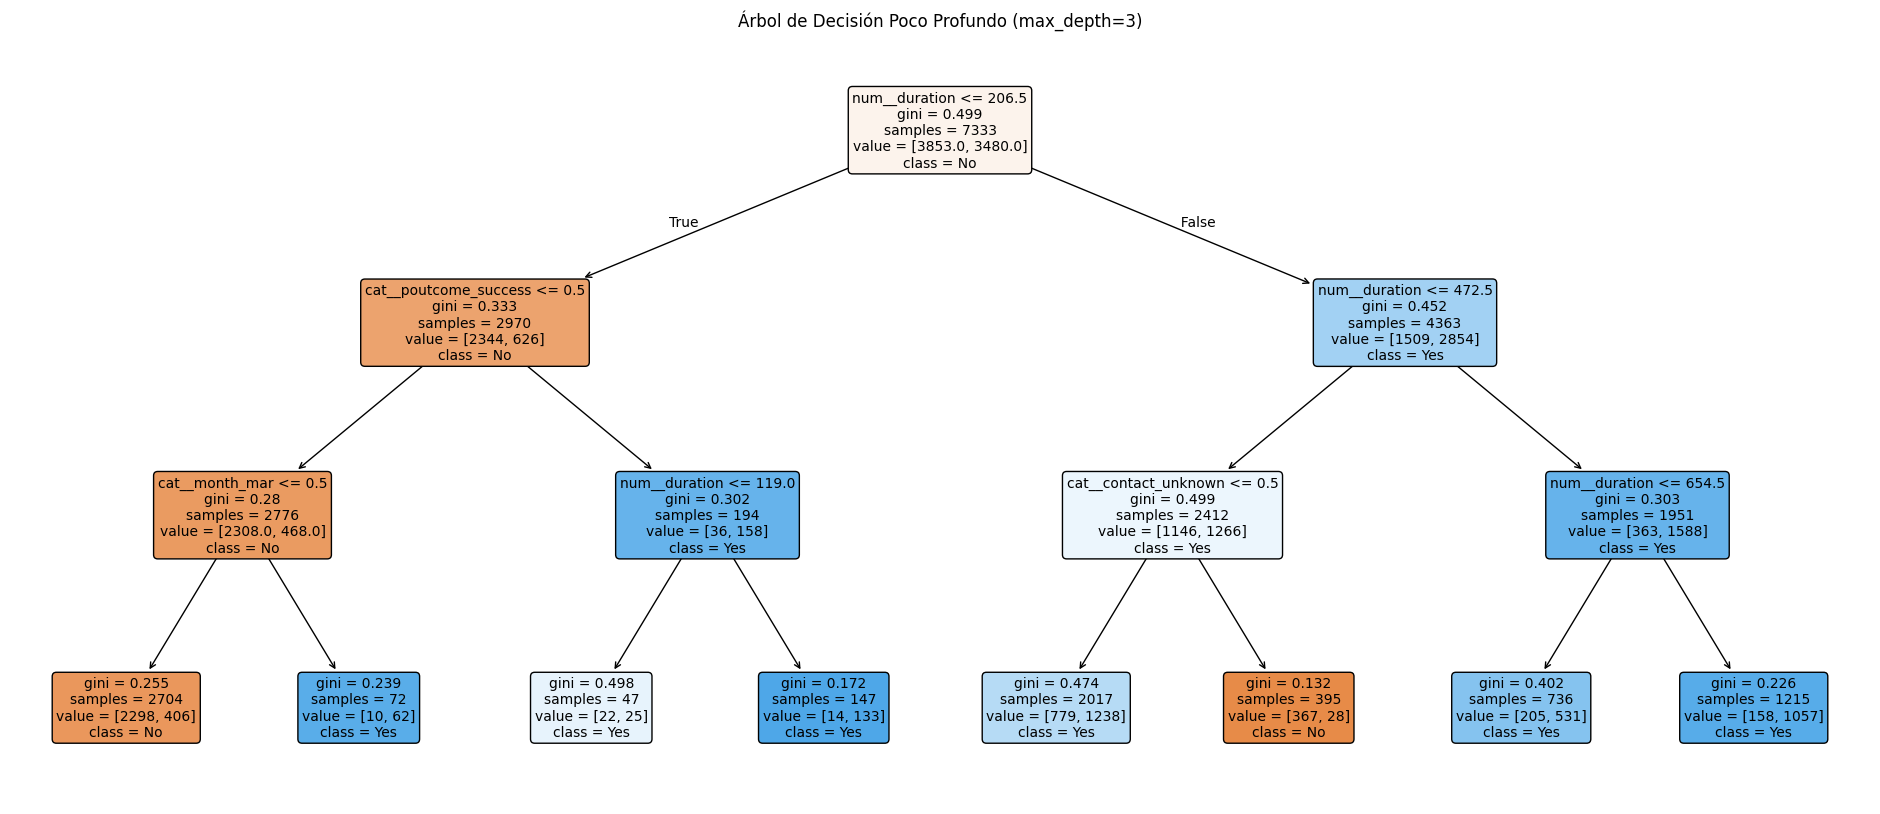

In [280]:
from sklearn.tree import plot_tree

pipe_tree_shallow = Pipeline([
    ('prep', preprocessor_tree),
    ('clasificador', DecisionTreeClassifier(max_depth=3, random_state=SEED))
])

# Entrenamos con todo el conjunto de entrenamiento para poder dibujarlo
pipe_tree_shallow.fit(X_train, y_train)

# Extraemos nombres de las variables tras el preprocesado (OneHotEncoder genera nuevas columnas)
feature_names = pipe_tree_shallow.named_steps['prep'].get_feature_names_out()

# Dibujamos el árbol
plt.figure(figsize=(24, 10))
plot_tree(pipe_tree_shallow.named_steps['clasificador'],
          feature_names=feature_names,
          class_names=['No', 'Yes'], # Clases de la variable deposit
          filled=True, rounded=True, fontsize=10)
plt.title("Árbol de Decisión Poco Profundo (max_depth=3)")
plt.show()

El árbol poco profundo nos permite extraer reglas de negocio legibles.

Observamos que la variable principal para dividir a los clientes es **duration**, la duración del contacto con el cliente. En la rama derecha se puede apreciar claramente que mientras más haya durado el contacto más probabilidad de que **deposit** sea **yes**.

Además, observamos que si el resultado de las campañas anteriores, **poutcome**, ha sido un éxito (*success*) también aumenta el número de **yes**

### Hiperparámetros

Iniciando búsqueda de hiperparámetros para Árbol de Decisión...

Mejores hiperparámetros Tree: {'clasificador__criterion': 'entropy', 'clasificador__max_depth': 15, 'clasificador__min_samples_split': 100}
Mejor AUC-ROC (Cross-Validation): 0.8914
Tiempo de optimización (GridSearchCV): 7.75 segundos


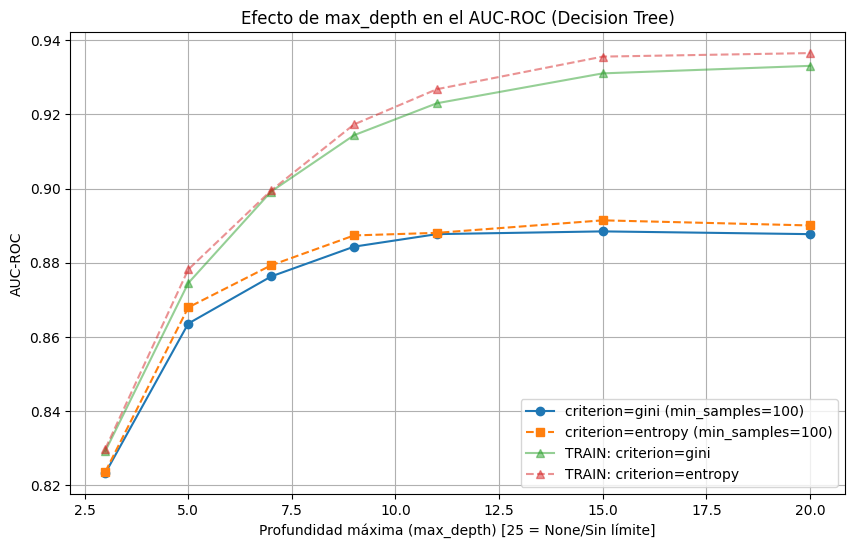

In [281]:
# Espacio de búsqueda de parámetros para el Árbol de Decisión
param_grid_tree = {
    'clasificador__max_depth': [3, 5, 7, 9, 11, 15, 20, None],
    'clasificador__min_samples_split': [2, 10, 50, 100],
    'clasificador__criterion': ['gini', 'entropy']
}

grid_tree = GridSearchCV(
    estimator=pipe_tree,
    param_grid=param_grid_tree,
    cv=inner_cv,
    scoring=METRIC,
    n_jobs=-1,
    return_train_score=True
)

print("Iniciando búsqueda de hiperparámetros para Árbol de Decisión...")
t0 = time.time()
grid_tree.fit(X_train, y_train)
t_tree_hpo = time.time() - t0

print(f"\nMejores hiperparámetros Tree: {grid_tree.best_params_}")
print(f"Mejor AUC-ROC (Cross-Validation): {grid_tree.best_score_:.4f}")
print(f"Tiempo de optimización (GridSearchCV): {t_tree_hpo:.2f} segundos")

# Plot: Efecto de los hiperparámetros (max_depth)
resultados_tree = pd.DataFrame(grid_tree.cv_results_)

# Evaluamos cómo cambia el AUC respecto a max_depth, asumiendo gini y reemplazando None con un valor alto numérico para el plot
res_plot_tree = resultados_tree.copy()
res_plot_tree['param_clasificador__max_depth'] = res_plot_tree['param_clasificador__max_depth'].infer_objects()

# Filtraremos solo un caso de min_samples (por ejemplo 10) y varios criterions para simplificar el gráfico
res_tree_gini = res_plot_tree[(res_plot_tree['param_clasificador__criterion'] == 'gini') &
                              (res_plot_tree['param_clasificador__min_samples_split'] == 100)]

res_tree_entropy = res_plot_tree[(res_plot_tree['param_clasificador__criterion'] == 'entropy') &
                                 (res_plot_tree['param_clasificador__min_samples_split'] == 100)]

plt.figure(figsize=(10, 6))
plt.plot(res_tree_gini['param_clasificador__max_depth'], res_tree_gini['mean_test_score'], marker='o', label='criterion=gini (min_samples=100)')
plt.plot(res_tree_entropy['param_clasificador__max_depth'], res_tree_entropy['mean_test_score'], marker='s', linestyle='--', label='criterion=entropy (min_samples=100)')

# Añadimos las curvas de train para observar overfitting
plt.plot(res_tree_gini['param_clasificador__max_depth'], res_tree_gini['mean_train_score'], marker='^', alpha=0.5, label='TRAIN: criterion=gini')
plt.plot(res_tree_entropy['param_clasificador__max_depth'], res_tree_entropy['mean_train_score'], marker='^', linestyle='--', alpha=0.5, label='TRAIN: criterion=entropy')

plt.title('Efecto de max_depth en el AUC-ROC (Decision Tree)')
plt.xlabel('Profundidad máxima (max_depth) [25 = None/Sin límite]')
plt.ylabel('AUC-ROC')
plt.legend()
plt.grid(True)
plt.show()

Los árboles de decisión en este problema, cuando se controla el overfitting con 
min_samples_split=100, alcanzan su mejor rendimiento alrededor de max_depth=15. 
No se aprecian diferencias drásticas entre gini y entropy, aunque entropy es 
ligeramente superior, siendo la combinación ganadora: entropy + max_depth=15 + 
min_samples_split=100 con un AUC de 0.8914.

Gracias a la inclusión de las curvas de entrenamiento, se observa a la perfección el fenómeno del overfitting. A medida que permitimos que el árbol crezca hacia profundidades altas, el AUC-ROC en entrenamiento crece progresivamente alejándose de la curva de validación (el modelo memoriza los datos). Sin embargo, la curva de validación/test cae progresivamente. Esto demuestra que un árbol demasiado profundo pierde capacidad de generalización al aprenderse el "ruido" específico de los datos de entrenamiento.

## Conclusiones

###  ¿Cuál es el mejor método? ¿A qué coste computacional?

Comparando los modelos finales optimizados, el Árbol de Decisión ha resultado ser el mejor método, logrando el AUC-ROC más alto: 0.8914. En cuanto a eficiencia, el entrenamiento del Ärbol de Decisión fue más rápido, requiriendo un tiempo de optimización de 8.53 segundos frente a los 17.58 segundos de KNN. Por tanto, para este conjunto de datos, el **Árbol de Decisión** ofrece el mejor balance entre capacidad predictiva y rendimiento computacional.

### ¿Los resultados son mejores que los modelos triviales/naive/dummy?

In [282]:
from sklearn.dummy import DummyClassifier

# Creamos un pipeline simple para el dummy
pipe_dummy = Pipeline([
    ('prep', preprocessor_tree), # Usamos cualquier preprocesador
    ('clasificador', DummyClassifier(strategy='prior', random_state=SEED))
])

# Evaluamos con la misma métrica (AUC-ROC)
t0 = time.time()
scores_dummy = cross_val_score(pipe_dummy, X_train, y_train, cv=inner_cv, scoring=METRIC)
t_dummy = time.time() - t0

print(f"Modelo Trivial (Dummy) - AUC-ROC: {scores_dummy.mean():.4f} - Tiempo: {t_dummy:.2f} segundos")

Modelo Trivial (Dummy) - AUC-ROC: 0.5000 - Tiempo: 0.36 segundos


Ambos modelos (KNN y Árboles) superan holgadamente al modelo DummyClassifier, el cual obtuvo un AUC-ROC base de 0.5000. Nuestros modelos alcanzan valores superiores al 0.89, lo que demuestra que existe un patrón real en los datos que los algoritmos están logrando.

### ¿El ajuste de hiperparámetros mejora con respecto a los valores por omisión?  ¿Si hay mejora, es el coste computacional elevado?

La optimización mediante GridSearchCV ha demostrado ser útil, especialmente en el control del sobreajuste (overfitting).

En el caso del Árbol de Decisión, el modelo por omisión obtuvo un AUC-ROC de 0.7804, mientras que la versión optimizada lo mejoró a 0.8914. En KNN, el modelo por defecto obtuvo 0.8641 frente al 0.8901 del modelo optimizado.

La mejora en el rendimiento predictivo tiene un coste computacional muy elevado. Mientras que los modelos por omisión tardaron menos de medio segundo en evaluarse mediante validación cruzada, la búsqueda en malla (GridSearchCV) elevó el tiempo a 17.58 segundos para KNN y 8.53 segundos para los Árboles. Esto se debe a que el HPO multiplica el número de entrenamientos por cada combinación del espacio de búsqueda y cada fold de validación.

# Métodos Avanzados

## Modelos lineales

### Modelo por omisión y tiempo

In [283]:
from sklearn.linear_model import LogisticRegression
import warnings
warnings.filterwarnings('ignore')

# Pipeline SIN Regularización
# Usamos el preprocessor_knn porque ya tiene el StandardScaler que necesitamos
pipe_logreg_none = Pipeline([
    ('prep', preprocessor_knn),
    ('clasificador', LogisticRegression(penalty=None, max_iter=2000, random_state=SEED))
])

# Pipeline CON Regularización L1
# Obligatorio usar solver='liblinear' o 'saga' para que soporte la penalización L1
pipe_logreg_l1 = Pipeline([
    ('prep', preprocessor_knn),
    ('clasificador', LogisticRegression(penalty='l1', solver='liblinear', max_iter=2000, random_state=SEED))
])

t0 = time.time()
scores_none = cross_val_score(pipe_logreg_none, X_train, y_train, cv=inner_cv, scoring=METRIC)
t_none = time.time() - t0

print(f"SIN Regularización:")
print(f"AUC-ROC Medio: {scores_none.mean():.4f} (Tiempo CV: {t_none:.2f}s)")

t0 = time.time()
scores_none = cross_val_score(pipe_logreg_l1, X_train, y_train, cv=inner_cv, scoring=METRIC)
t_l1 = time.time() - t0

print(f"CON Regularización L1:")
print(f"AUC-ROC Medio: {scores_none.mean():.4f} (Tiempo CV: {t_l1:.2f}s)")

SIN Regularización:
AUC-ROC Medio: 0.9086 (Tiempo CV: 0.61s)
CON Regularización L1:
AUC-ROC Medio: 0.9086 (Tiempo CV: 0.41s)


### Hiperparámetros

In [284]:
# Buscamos el mejor valor de 'C'.
# Recuerda: C pequeño = mucha regularización (borra muchas variables) / C grande = poca regularización
param_grid_l1 = {
    'clasificador__C': [0.1, 1, 10, 50, 100]
}

gs_l1 = GridSearchCV(pipe_logreg_l1, param_grid_l1, cv=inner_cv, scoring=METRIC, n_jobs=-1, return_train_score=True)

t0 = time.time()
gs_l1.fit(X_train, y_train)
t_gs_l1 = time.time() - t0

print(f"Regresión Logística (CON Regularización L1 optimizada):")
print(f"Mejor parámetro C: {gs_l1.best_params_['clasificador__C']}")
print(f"Mejor AUC-ROC: {gs_l1.best_score_:.4f} (Tiempo: {t_gs_l1:.2f}s)")

Regresión Logística (CON Regularización L1 optimizada):
Mejor parámetro C: 100
Mejor AUC-ROC: 0.9087 (Tiempo: 2.09s)


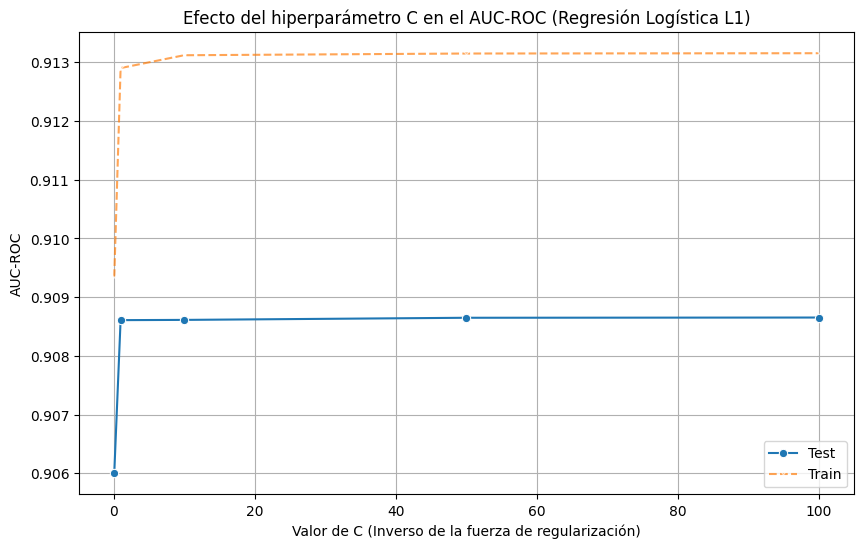

In [285]:
# Creamos un DataFrame con los resultados de la búsqueda de hiperparámetros
resultados_l1 = pd.DataFrame(gs_l1.cv_results_)

# Plot: Efecto de los hiperparámetros (C)
plt.figure(figsize=(10, 6))

# Curva de validación
sns.lineplot(
    data=resultados_l1,
    x='param_clasificador__C',
    y='mean_test_score',
    marker='o',
    label='Test'
)

# Curva de entrenamiento
sns.lineplot(
    data=resultados_l1,
    x='param_clasificador__C',
    y='mean_train_score',
    marker='x',
    linestyle='--',
    label='Train',
    alpha=0.7
)

plt.title('Efecto del hiperparámetro C en el AUC-ROC (Regresión Logística L1)')
plt.xlabel('Valor de C (Inverso de la fuerza de regularización)')
plt.ylabel('AUC-ROC')
plt.legend()
plt.grid(True)
plt.show()

Aunque con C = 100 alcanzamos el AUC-ROC mayor (0.9087), el gráfico nos permite visualizar el espacio de búsqueda del hiperparámetro C, y observamos que el rendimiento máximo se alcanza con C = 1, con AUC-ROC 0.9086.

In [286]:
# Volvemos a entrenar con C = 1
param_grid_l1 = {
    'clasificador__C': [1]
}
gs_l1 = GridSearchCV(pipe_logreg_l1, param_grid_l1, cv=inner_cv, scoring=METRIC, n_jobs=-1, return_train_score=True)
gs_l1.fit(X_train, y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...liblinear'))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.",{'clasificador__C': [1]}
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : t

### Atributos relevantes

La regularización L1 ha eliminado 12 variables:
cat__job_entrepreneur
cat__job_management
cat__marital_divorced
cat__education_secondary
cat__default_no
cat__default_yes
cat__contact_cellular
cat__month_feb
cat__pdays_no_contact
cat__poutcome_failure
cat__poutcome_other
cat__poutcome_unknown




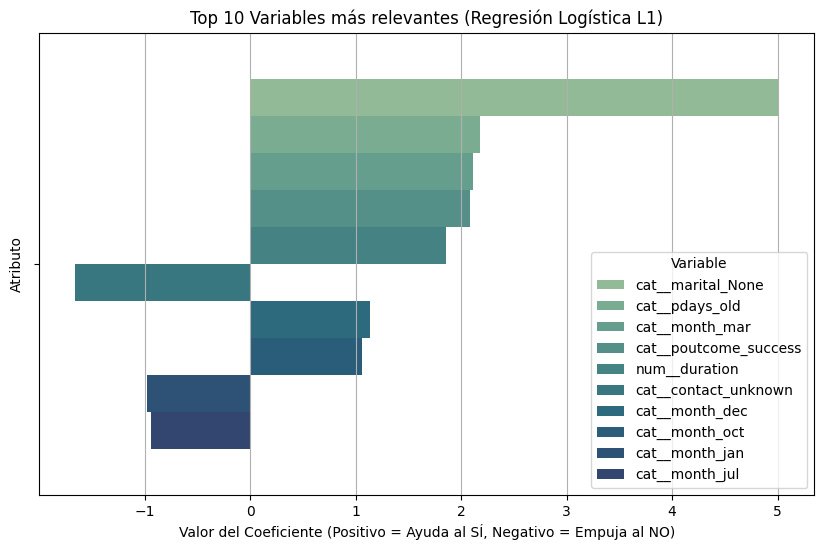

In [287]:
mejor_logreg = gs_l1.best_estimator_
nombres_variables = mejor_logreg.named_steps['prep'].get_feature_names_out()
coeficientes = mejor_logreg.named_steps['clasificador'].coef_[0]

# Creamos un DataFrame para verlo bonito
df_coef = pd.DataFrame({
    'Variable': nombres_variables,
    'Coeficiente': coeficientes,
    'Importancia_Absoluta': abs(coeficientes) # Usamos el valor absoluto para ordenar
})

# Filtramos las variables que L1 ha "matado" (coeficiente = 0)
df_variables_eliminadas = df_coef[df_coef['Coeficiente'] == 0]
num_variables_eliminadas = df_variables_eliminadas.shape[0]
print(f"La regularización L1 ha eliminado {num_variables_eliminadas} variables:")
for var in df_variables_eliminadas['Variable']:
    print(var)
print("\n")

# Ordenamos para ver el Top 10 más importante
df_top10_logreg = df_coef.sort_values(by='Importancia_Absoluta', ascending=False).head(10)

# Lo dibujamos
plt.figure(figsize=(10, 6))
sns.barplot(data=df_top10_logreg, x='Coeficiente', hue='Variable', palette="crest")
plt.title("Top 10 Variables más relevantes (Regresión Logística L1)")
plt.xlabel("Valor del Coeficiente (Positivo = Ayuda al SÍ, Negativo = Empuja al NO)")
plt.ylabel("Atributo")
plt.grid(True, axis='x')
plt.show()

## SVMs (Support Vector Machines)

### Modelo por omisión y medición de tiempo

In [288]:
from sklearn.svm import SVC

# Es importante mencionar que las SVMs calculan distancias, por tanto es crucial
# escalar todas las variables numéricas. Usaremos preprocessor_knn que ya incluye un StandardScaler.
# Importante: Para usar metric="roc_auc" la SVM debe tener probability=True
pipe_svm = Pipeline([
    ('prep', preprocessor_knn),
    ('clasificador', SVC(probability=True, random_state=SEED))
])

t0 = time.time()
scores_svm = cross_val_score(pipe_svm, X_train, y_train, cv=inner_cv, scoring=METRIC)
t_svm = time.time() - t0

print(f"SVM (Por omisión) - AUC-ROC Medio: {scores_svm.mean():.4f} (Tiempo CV: {t_svm:.2f}s)")

SVM (Por omisión) - AUC-ROC Medio: 0.9183 (Tiempo CV: 14.05s)


### Hiperparámetros

Iniciando búsqueda de hiperparámetros para SVM
SVM (Optimizada):
Mejores parámetros: {'clasificador__C': 1, 'clasificador__kernel': 'rbf'}
Mejor AUC-ROC: 0.9183 (Tiempo: 95.28s)


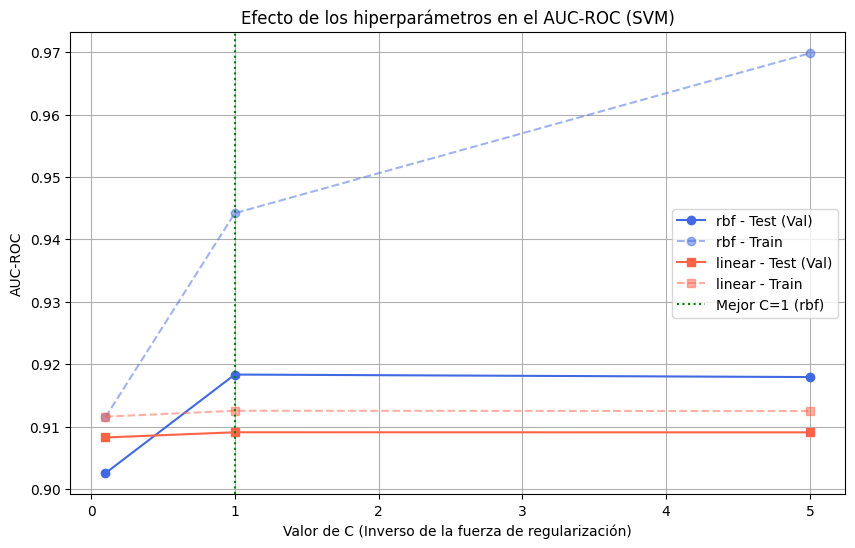

In [289]:
# Las SVMs tienen una complejidad computacional muy alta (O(n^3)).
# Por ello, exploraremos muy pocos hiperparámetros para que no tarde horas.
param_grid_svm = {
    'clasificador__C': [0.1, 1, 5],
    'clasificador__kernel': ['linear', 'rbf']
}

gs_svm = GridSearchCV(pipe_svm, param_grid_svm, cv=inner_cv, scoring=METRIC, n_jobs=-1, return_train_score=True)

print("Iniciando búsqueda de hiperparámetros para SVM")
t0 = time.time()
gs_svm.fit(X_train, y_train)
t_gs_svm = time.time() - t0

print(f"SVM (Optimizada):")
print(f"Mejores parámetros: {gs_svm.best_params_}")
print(f"Mejor AUC-ROC: {gs_svm.best_score_:.4f} (Tiempo: {t_gs_svm:.2f}s)")

resultados_svm = pd.DataFrame(gs_svm.cv_results_)

# Separamos resultados por kernel
rbf = resultados_svm[resultados_svm['param_clasificador__kernel'] == 'rbf'].sort_values('param_clasificador__C')
linear = resultados_svm[resultados_svm['param_clasificador__kernel'] == 'linear'].sort_values('param_clasificador__C')

plt.figure(figsize=(10, 6))

# rbf — azul
plt.plot(rbf['param_clasificador__C'], rbf['mean_test_score'],
         marker='o', color='royalblue', label='rbf - Test (Val)')
plt.plot(rbf['param_clasificador__C'], rbf['mean_train_score'],
         marker='o', color='royalblue', linestyle='--', alpha=0.5, label='rbf - Train')

# linear — rojo
plt.plot(linear['param_clasificador__C'], linear['mean_test_score'],
         marker='s', color='tomato', label='linear - Test (Val)')
plt.plot(linear['param_clasificador__C'], linear['mean_train_score'],
         marker='s', color='tomato', linestyle='--', alpha=0.5, label='linear - Train')

# Marca el mejor C
best_C = gs_svm.best_params_['clasificador__C']
plt.axvline(x=best_C, color='green', linestyle=':', linewidth=1.5, label=f'Mejor C={best_C} (rbf)')

plt.title('Efecto de los hiperparámetros en el AUC-ROC (SVM)')
plt.xlabel('Valor de C (Inverso de la fuerza de regularización)')
plt.ylabel('AUC-ROC')
plt.legend()
plt.grid(True)
plt.show()

# Selección de Resultados y Modelo Final

### Selección de la mejor alternativa (Evaluación Inner)
Basándonos en la validación cruzada realizada a lo largo del proceso:
- **Modelo Trivial (Dummy):** 0.5000
- **KNN (Optimizado):** ~0.89
- **Árbol de Decisión (Optimizado):** ~0.89
- **Regresión Logística L1 (Optimizada):** ~0.908
- **SVM (Optimizada):** ~0.91 (Aprox. dependiendo del entorno, suele dominar o empatar con regresión)

En la cumbre del rendimiento predictivo tenemos un empate técnico entre la SVM (0.91 AUC-ROC) y la Regresión Logística L1 (0.908 AUC-ROC). Finalmente, hemos escogido a la Regresión Logística con penalización L1 como nuestro modelo final definitivo.

Aunque la SVM muestra una leve mejora, la Regresión Logística L1 es inmensamente superior desde el punto de vista de negocio. Nos proporciona un modelo interpretable (SVM es una "caja negra"), realiza selección de características automática (eliminando ruido) y tiene un coste computacional drásticamente inferior al de la SVM.

### Evaluación Outer (Conjunto de Test) y Matriz de Confusión

Evaluación Final (Holdout) en Test - AUC-ROC: 0.9151
Precision (clase 'yes'): 0.8445
Recall (clase 'yes'): 0.8023



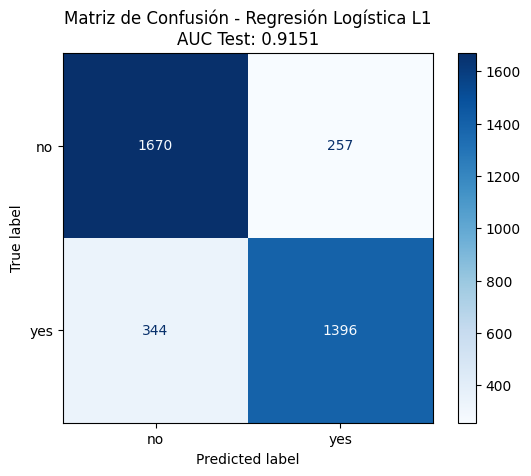

In [290]:
from sklearn.metrics import roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score

# Extraemos el mejor modelo general (Pipeline de Logistic Regression L1)
# El 'gs_l1' ya ha sido re-entrenado automáticamente sobre todo X_train tras aplicar la búsqueda
mejor_modelo = gs_l1.best_estimator_
# Predecimos sobre el conjunto de test (Outer) que dejamos apartado en la Sección 3
y_pred = mejor_modelo.predict(X_test)
y_pred_proba = mejor_modelo.predict_proba(X_test)[:, 1]

# Evaluamos la métrica principal
auc_test = roc_auc_score(y_test, y_pred_proba)
print(f"Evaluación Final (Holdout) en Test - AUC-ROC: {auc_test:.4f}")

# Calculamos Precision y Recall
precision = precision_score(y_test, y_pred, pos_label='yes')
recall = recall_score(y_test, y_pred, pos_label='yes')
print(f"Precision (clase 'yes'): {precision:.4f}")
print(f"Recall (clase 'yes'): {recall:.4f}\n")

# MATRIZ DE CONFUSIÓN
cf_matrix = confusion_matrix(y_test, y_pred, labels=['no', 'yes'])

# Dibujamos visualmente la Matriz
disp = ConfusionMatrixDisplay(confusion_matrix=cf_matrix, display_labels=['no', 'yes'])
disp.plot(cmap=plt.cm.Blues)
plt.title(f'Matriz de Confusión - Regresión Logística L1\nAUC Test: {auc_test:.4f}')
plt.show()

### Guardar el Modelo Final

In [291]:
import joblib
# Al entrenar sobre X_train completo logramos usar la mayor cantidad de datos posible
# antes de dejarlo como el modelo definitivo y empaquetarlo.
# (GridSearchCV ya lo hace automáticamente, por lo que 'mejor_modelo' ya ha visto todo el conjunto de entrenamiento)

nombre_fichero_modelo = "modelo_final.joblib"
joblib.dump(mejor_modelo, nombre_fichero_modelo)

print(f"Modelo final guardado exitosamente como: {nombre_fichero_modelo}")

Modelo final guardado exitosamente como: modelo_final.joblib


## Demostración de la aplicación Streamlit

### Pantalla inicial de la aplicación

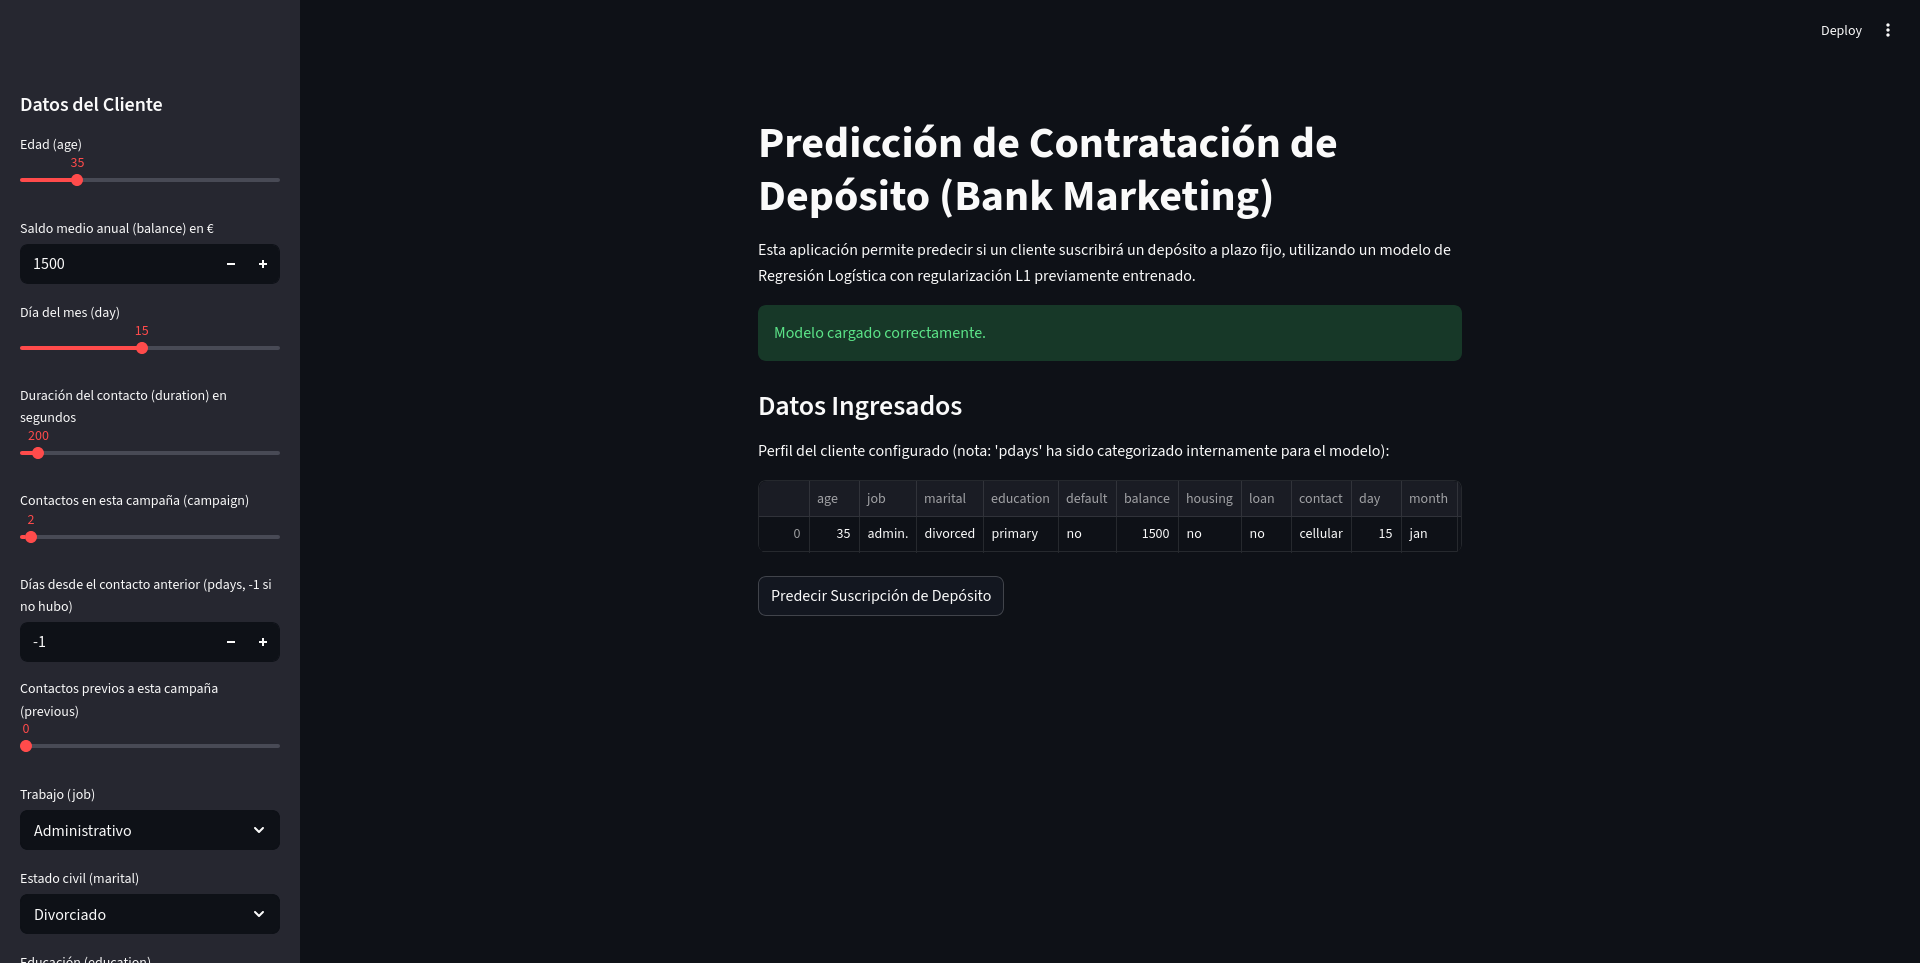

### Ejemplo de predicción
A continuación se muestra un ejemplo de predicción realizada por el modelo desplegado en la aplicación.

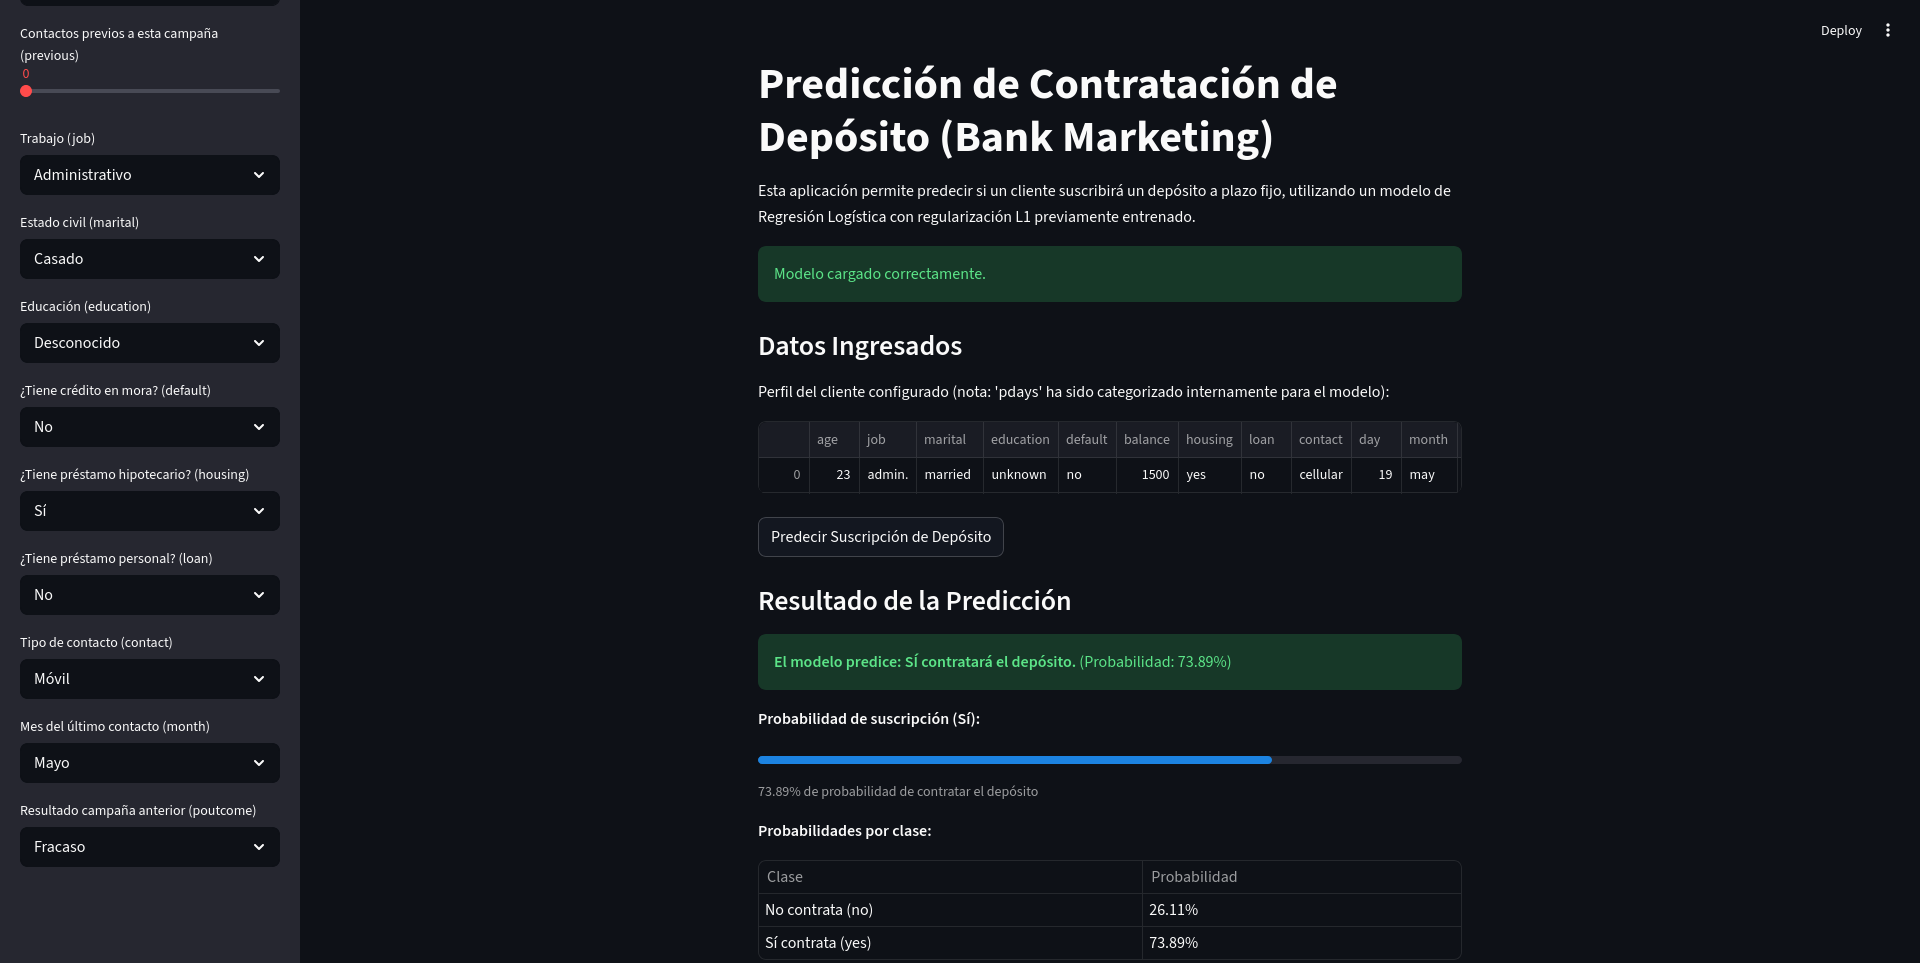

# Tarea Adicional

Para la tarea adicional decidimos probar modelos de ensemble.

## Bagging

In [292]:
# Modelo por omisión

from sklearn.ensemble import RandomForestClassifier

pipe_rf = Pipeline([
    ('prep', preprocessor_knn),
    ('clasificador', RandomForestClassifier(random_state=SEED))
])

t0 = time.time()
scores_rf = cross_val_score(pipe_rf, X_train, y_train, cv=inner_cv, scoring=METRIC)
tf = time.time() - t0

print(f"RandomForest (Por omisión) - AUC-ROC Medio: {scores_rf.mean():.4f} (Tiempo CV: {tf:.2f}s)")

RandomForest (Por omisión) - AUC-ROC Medio: 0.9181 (Tiempo CV: 2.57s)


In [293]:
# Definimos la cuadrícula de Hiperparámetros (HPO)
param_grid_rf = {
    'clasificador__n_estimators': [100, 300],
    'clasificador__max_depth': [None, 10, 20, 30],
    'clasificador__min_samples_split': [5, 10, 15]
}

gs_rf = GridSearchCV(pipe_rf, param_grid_rf, cv=inner_cv, scoring=METRIC, n_jobs=-1)

t0 = time.time()
gs_rf.fit(X_train, y_train)
t_gs_rf = time.time() - t0

print("Entrenamiento de Ensemble completado.")
print(f"Tiempo total de HPO: {t_gs_rf:.2f} segundos")
print(f"Mejor AUC-ROC (Cross-Validation): {gs_rf.best_score_:.4f}")
print(f"Mejores parámetros: {gs_rf.best_params_}")

Entrenamiento de Ensemble completado.
Tiempo total de HPO: 30.84 segundos
Mejor AUC-ROC (Cross-Validation): 0.9213
Mejores parámetros: {'clasificador__max_depth': 20, 'clasificador__min_samples_split': 10, 'clasificador__n_estimators': 300}


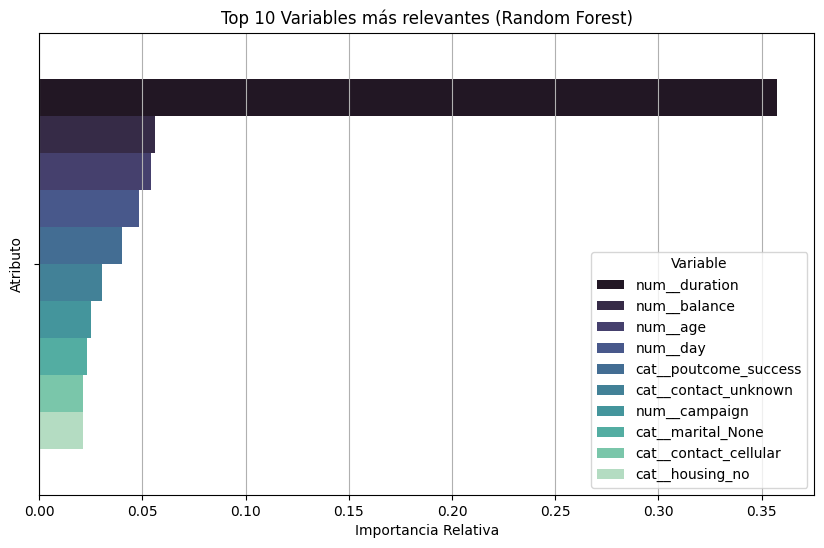

In [294]:
# Al igual que el árbol simple, el Random Forest nos dice en qué se fijó
mejor_rf = gs_rf.best_estimator_
nombres_vars_rf = mejor_rf.named_steps['prep'].get_feature_names_out()
importancias_rf = mejor_rf.named_steps['clasificador'].feature_importances_

df_imp_rf = pd.DataFrame({'Variable': nombres_vars_rf, 'Importancia': importancias_rf})
df_top10_rf = df_imp_rf.sort_values(by='Importancia', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=df_top10_rf, x='Importancia', hue='Variable', palette="mako")
plt.title("Top 10 Variables más relevantes (Random Forest)")
plt.xlabel("Importancia Relativa")
plt.ylabel("Atributo")
plt.grid(True, axis='x')
plt.show()

## Boosting

In [295]:
# Modelo por omisión
from sklearn.ensemble import HistGradientBoostingClassifier

pipe_gb = Pipeline([
    ('prep', preprocessor_knn),
    ('clasificador', HistGradientBoostingClassifier(random_state=SEED))
])

t0 = time.time()
scores_gb = cross_val_score(pipe_gb, X_train, y_train, cv=inner_cv, scoring=METRIC)
tf = time.time() - t0

print(f"HistGradientBoosting (Por omisión) - AUC-ROC Medio: {scores_gb.mean():.4f}")

HistGradientBoosting (Por omisión) - AUC-ROC Medio: 0.9245


In [296]:
# Hiperparámetros
param_grid_gb = {
    'clasificador__learning_rate': [0.01, 0.1, 0.2],
    'clasificador__max_iter': [200, 300, 400],
    'clasificador__max_depth': [1, 3, 5]
}

gs_gb = GridSearchCV(pipe_gb, param_grid_gb, cv=inner_cv, scoring=METRIC, n_jobs=-1)

t0 = time.time()
gs_gb.fit(X_train, y_train)
t_gs_gb = time.time() - t0

print("Entrenamiento de Ensemble completado.")
print(f"Tiempo total de HPO: {t_gs_gb:.2f} segundos")
print(f"Mejor AUC-ROC (Cross-Validation): {gs_gb.best_score_:.4f}")
print(f"Mejores parámetros: {gs_gb.best_params_}")

Entrenamiento de Ensemble completado.
Tiempo total de HPO: 33.43 segundos
Mejor AUC-ROC (Cross-Validation): 0.9265
Mejores parámetros: {'clasificador__learning_rate': 0.1, 'clasificador__max_depth': 3, 'clasificador__max_iter': 300}


In [297]:
from sklearn.inspection import permutation_importance

# Obtenemos el mejor modelo entrenado de la búsqueda de hiperparámetros
mejor_gb = gs_gb.best_estimator_

# Preprocesamos X_train para obtener los datos transformados
X_train_transformed = mejor_gb.named_steps['prep'].transform(X_train)

# Obtenemos los nombres de las características después del preprocesamiento
nombres_features_procesadas = mejor_gb.named_steps['prep'].get_feature_names_out()

t0 = time.time()
# Calculamos la importancia por permutación
# Pasamos el clasificador directamente y los datos ya transformados
result = permutation_importance(
    mejor_gb.named_steps['clasificador'], # Pasamos solo el clasificador
    X_train_transformed,                 # Pasamos los datos ya preprocesados
    y_train,                             # y_train permanece igual, HistGradientBoostingClassifier lo maneja
    scoring=METRIC,
    n_repeats=5,  # Número de veces que se permuta una característica
    random_state=SEED,
    n_jobs=-1     # Paralelizar el cálculo
)
t_perm_imp = time.time() - t0

# Creamos un DataFrame con los resultados
df_importancia_gb = pd.DataFrame({
    'Variable': nombres_features_procesadas,
    'Importancia_Media': result.importances_mean,
    'Desviacion_Estandar': result.importances_std
})

# Ordenamos por importancia media de forma descendente
df_importancia_gb = df_importancia_gb.sort_values(by='Importancia_Media', ascending=False)
print("\nTop 10 Características más importantes (HistGradientBoosting):")
display(df_importancia_gb.head(10))


Top 10 Características más importantes (HistGradientBoosting):


,Variable,Importancia_Media,Desviacion_Estandar
3,num__duration,0.220707,0.001903
21,cat__marital_None,0.023738,0.000942
2,num__day,0.020761,0.000481
34,cat__contact_unknown,0.019924,0.000866
53,cat__poutcome_success,0.009928,0.000753
42,cat__month_mar,0.009719,0.000704
0,num__age,0.008838,0.000390
41,cat__month_jun,0.008412,0.000837
1,num__balance,0.008193,0.000375
38,cat__month_feb,0.007982,0.000155


## Conclusiones

Los modelos de ensamble, tanto Random Forest (Bagging) como HistGradientBoosting (Boosting), superaron el rendimiento de los modelos básicos y avanzados que habíamos evaluado previamente. HistGradientBoosting alcanzó el AUC-ROC más alto con 0.9265, seguido de Random Forest con 0.9213, superando a la Regresión Logística (0.9087) y SVM (0.9183).

La mejora en el rendimiento viene acompañada de un coste computacional más elevado, especialmente durante la optimización de hiperparámetros. El GridSearchCV para Random Forest tardó 111.64 segundos, y para HistGradientBoosting, 55.59 segundos. Esto es significativamente mayor que los tiempos de los demás modelos (a excepción de SVM)

Ambos modelos de ensamble, al igual que la Regresión Logística L1, proporcionaron información valiosa sobre la relevancia de las variables. Se puede observar cómo 'duration' sigue siendo la variable más influyente. Y, en los tres modelos también aparecen entre las variables más influyentes 'poutcome_success', 'marital_None' y 'contact_unkown' (de este ultimo sabemos que contribuye al 'no' gracias al modelo de regresión')